<a href="https://colab.research.google.com/github/sjdyeet/concept_of_ai/blob/main/classifaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
DATA_PATH = "/content/drive/MyDrive/student_lifestyle.csv.xlsx"
SHEET_NAME = "student_lifestyle_100k"
TARGET = "Depression"

print("File exists:", DATA_PATH)


File exists: /content/drive/MyDrive/student_lifestyle.csv.xlsx


In [14]:
import pandas as pd

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()


Shape: (49784, 11)
Columns:
['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression']


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [15]:
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
df.shape, df.columns.tolist()

((49784, 11),
 ['Student_ID',
  'Age',
  'Gender',
  'Department',
  'CGPA',
  'Sleep_Duration',
  'Study_Hours',
  'Social_Media_Hours',
  'Physical_Activity',
  'Stress_Level',
  'Depression'])

In [31]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


In [32]:
## 1) Dataset quality checks (missing values, imbalance, noise)

In [33]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]


,0


In [34]:
df[TARGET].value_counts(dropna=False)


,count
Depression,
False,44755
True,5029


In [35]:
import os

OUT_DIR = "/content/drive/MyDrive/outputs/classification"
os.makedirs(OUT_DIR, exist_ok=True)

print("Output folder ready:", OUT_DIR)


Output folder ready: /content/drive/MyDrive/outputs/classification


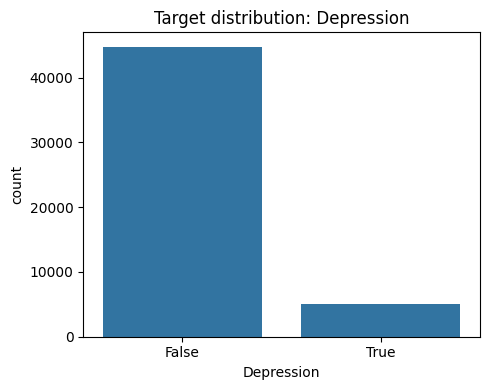

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x=TARGET, data=df)
plt.title(f'Target distribution: {TARGET}')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'target_distribution.png'), dpi=200)
plt.show()


In [37]:
## 2) EDA: summary statistics + visualizations

In [38]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Student_ID,49784.0,25892.500000,14371.547238,1001.00,13446.75,25892.5,38338.25,50784.0
Age,49784.0,21.002109,1.999954,18.00,19.00,21.0,23.00,24.0
CGPA,49784.0,2.898195,0.532567,1.59,2.45,2.9,3.35,4.0
Sleep_Duration,49784.0,6.996268,1.505165,3.00,6.00,7.0,8.00,12.0
Study_Hours,49784.0,4.504246,1.977472,0.00,3.10,4.5,5.80,12.6
Social_Media_Hours,49784.0,3.505385,1.488222,0.00,2.50,3.5,4.50,10.0
Physical_Activity,49784.0,74.186506,43.365876,0.00,37.00,74.0,112.00,149.0
Stress_Level,49784.0,4.144464,1.419367,2.00,3.00,4.0,5.00,10.0


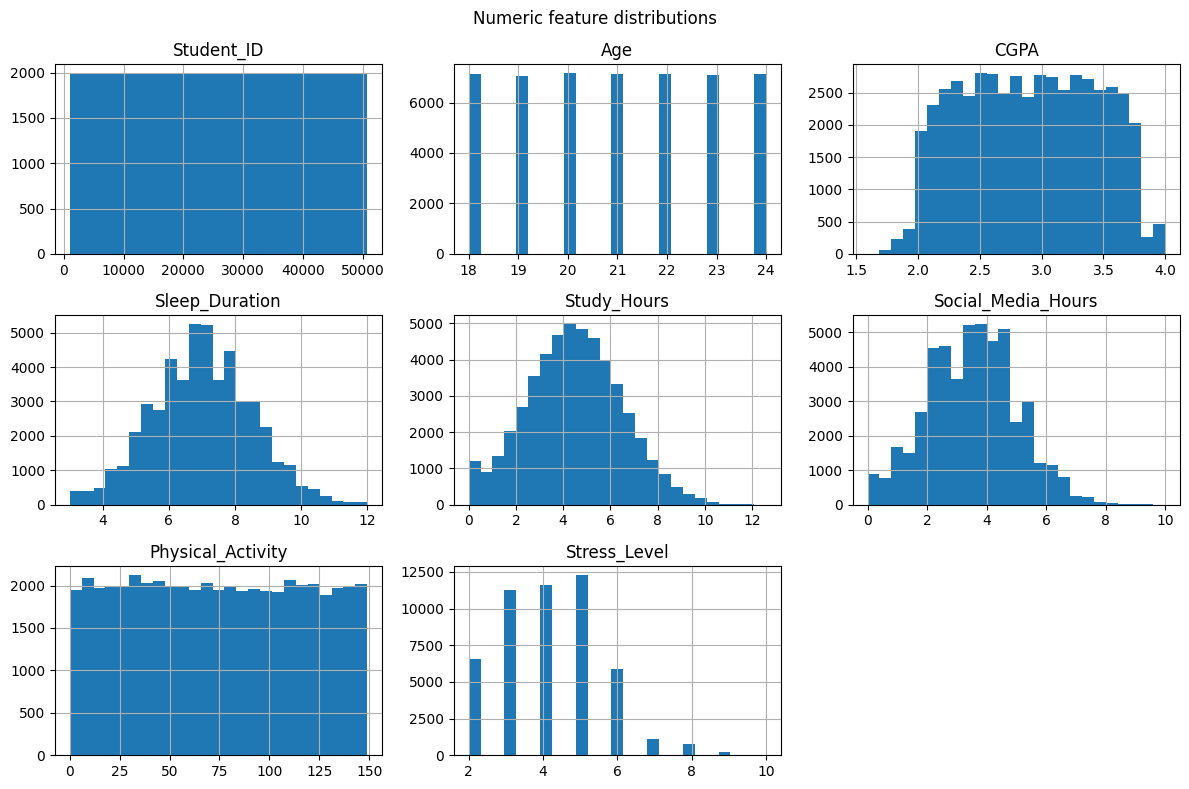

In [39]:
ax = df[num_cols].hist(bins=25, figsize=(12,8))
plt.suptitle('Numeric feature distributions')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'numeric_histograms.png'), dpi=200)
plt.show()


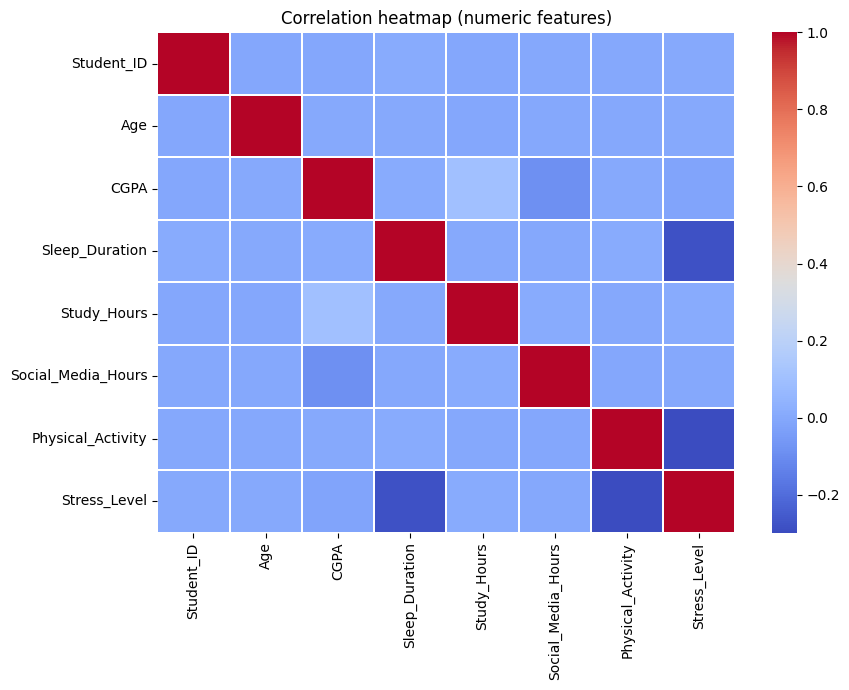

In [40]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(9,7))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.2)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'correlation_heatmap.png'), dpi=200)
plt.show()


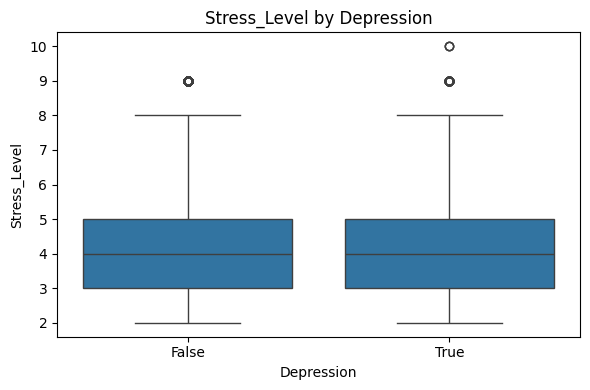

In [41]:
if 'Stress_Level' in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=TARGET, y='Stress_Level', data=df)
    plt.title('Stress_Level by Depression')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, 'stress_by_depression.png'), dpi=200)
    plt.show()


In [42]:
## 3) Train/test split + preprocessing

In [43]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape, y_train.value_counts(normalize=True)


((39827, 10),
 (9957, 10),
 Depression
 0    0.898988
 1    0.101012
 Name: proportion, dtype: float64)

In [44]:
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols, num_cols


(['Gender', 'Department'],
 ['Student_ID',
  'Age',
  'CGPA',
  'Sleep_Duration',
  'Study_Hours',
  'Social_Media_Hours',
  'Physical_Activity',
  'Stress_Level'])

In [45]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
])


In [46]:
## 4) Task 3: Two classical ML models

In [47]:
def eval_clf(model, name):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    metrics = {
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, pred_train),
        'Test Accuracy': accuracy_score(y_test, pred_test),
        'Test Precision': precision_score(y_test, pred_test, zero_division=0),
        'Test Recall': recall_score(y_test, pred_test, zero_division=0),
        'Test F1': f1_score(y_test, pred_test, zero_division=0),
    }

    print(name)
    print('Confusion matrix (test):')
    print(confusion_matrix(y_test, pred_test))
    print(classification_report(y_test, pred_test, zero_division=0))
    return metrics

# Handle class imbalance using class_weight='balanced'
lr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=3000, solver='lbfgs', class_weight='balanced')),
])

rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample',
    )),
])

baseline = []
baseline.append(eval_clf(lr, 'Logistic Regression (balanced)'))
baseline.append(eval_clf(rf, 'Random Forest (balanced)'))
pd.DataFrame(baseline).sort_values('Test F1', ascending=False)

Logistic Regression (balanced)
Confusion matrix (test):
[[5527 3424]
 [ 315  691]]
              precision    recall  f1-score   support

           0       0.95      0.62      0.75      8951
           1       0.17      0.69      0.27      1006

    accuracy                           0.62      9957
   macro avg       0.56      0.65      0.51      9957
weighted avg       0.87      0.62      0.70      9957

Random Forest (balanced)
Confusion matrix (test):
[[8947    4]
 [ 998    8]]
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      8951
           1       0.67      0.01      0.02      1006

    accuracy                           0.90      9957
   macro avg       0.78      0.50      0.48      9957
weighted avg       0.88      0.90      0.85      9957



,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression (balanced),0.620383,0.624485,0.167922,0.686879,0.269869
1,Random Forest (balanced),1.000000,0.899367,0.666667,0.007952,0.015717


In [48]:
## 5) Task 2: Neural network classifier (MLP)

In [49]:
mlp = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=50,
        random_state=RANDOM_STATE,
    )),
])
baseline.append(eval_clf(mlp, 'Neural Net (MLPClassifier)'))
pd.DataFrame(baseline).sort_values('Test F1', ascending=False)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Net (MLPClassifier)
Confusion matrix (test):
[[8898   53]
 [ 963   43]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.95      8951
           1       0.45      0.04      0.08      1006

    accuracy                           0.90      9957
   macro avg       0.68      0.52      0.51      9957
weighted avg       0.86      0.90      0.86      9957



,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression (balanced),0.620383,0.624485,0.167922,0.686879,0.269869
2,Neural Net (MLPClassifier),0.900018,0.897961,0.447917,0.042744,0.078040
1,Random Forest (balanced),1.000000,0.899367,0.666667,0.007952,0.015717


In [50]:
## 6) Task 4: Hyperparameter tuning with cross-validation (GridSearchCV)

In [51]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0],
}
rf_grid = {
    'model__n_estimators': [300, 600],
    'model__max_depth': [None, 8, 16],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

lr_search = GridSearchCV(lr, lr_grid, cv=cv, scoring='f1', n_jobs=1)
rf_search = GridSearchCV(rf, rf_grid, cv=cv, scoring='f1', n_jobs=1)

lr_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)

lr_search.best_params_, lr_search.best_score_, rf_search.best_params_, rf_search.best_score_

({'model__C': 0.01},
 np.float64(0.26554005191048435),
 {'model__max_depth': 8,
  'model__min_samples_leaf': 2,
  'model__min_samples_split': 5,
  'model__n_estimators': 600},
 np.float64(0.32335103006727445))

In [52]:
## 7) Task 5: Feature Selection (filter method)

In [53]:
selector = SelectKBest(score_func=mutual_info_classif, k=10)

# Final models: tuned hyperparameters + feature selection
lr_final = Pipeline(steps=[
    ('preprocess', preprocess),
    ('select', selector),
    ('model', LogisticRegression(
        max_iter=3000,
        solver='lbfgs',
        class_weight='balanced',
        C=lr_search.best_params_['model__C'],
    )),
])

rf_final = Pipeline(steps=[
    ('preprocess', preprocess),
    ('select', selector),
    ('model', RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample',
        n_estimators=rf_search.best_params_['model__n_estimators'],
        max_depth=rf_search.best_params_['model__max_depth'],
        min_samples_split=rf_search.best_params_['model__min_samples_split'],
        min_samples_leaf=rf_search.best_params_['model__min_samples_leaf'],
    )),
])

final_rows = []
final_rows.append(eval_clf(lr_final, 'LogReg (tuned + FS, balanced)'))
final_rows.append(eval_clf(rf_final, 'RF (tuned + FS, balanced)'))
final_rows

LogReg (tuned + FS, balanced)
Confusion matrix (test):
[[5512 3439]
 [ 313  693]]
              precision    recall  f1-score   support

           0       0.95      0.62      0.75      8951
           1       0.17      0.69      0.27      1006

    accuracy                           0.62      9957
   macro avg       0.56      0.65      0.51      9957
weighted avg       0.87      0.62      0.70      9957

RF (tuned + FS, balanced)
Confusion matrix (test):
[[6724 2227]
 [ 380  626]]
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      8951
           1       0.22      0.62      0.32      1006

    accuracy                           0.74      9957
   macro avg       0.58      0.69      0.58      9957
weighted avg       0.87      0.74      0.79      9957



[{'Model': 'LogReg (tuned + FS, balanced)',
  'Train Accuracy': 0.621010872021493,
  'Test Accuracy': 0.6231796725921462,
  'Test Precision': 0.16771539206195546,
  'Test Recall': 0.6888667992047713,
  'Test F1': 0.26975476839237056},
 {'Model': 'RF (tuned + FS, balanced)',
  'Train Accuracy': 0.7392221357370627,
  'Test Accuracy': 0.7381741488400121,
  'Test Precision': 0.21941815632667366,
  'Test Recall': 0.6222664015904572,
  'Test F1': 0.32443638248250845}]

In [54]:
## 8) Task 6: Final comparative table (Table 1 format)

In [55]:
table1 = pd.DataFrame(final_rows)
table1.insert(1, 'Features', ['Selected (k=10)', 'Selected (k=10)'])
table1.insert(2, 'CV Score (F1)', [lr_search.best_score_, rf_search.best_score_])
table1 = table1[[
    'Model', 'Features', 'CV Score (F1)',
    'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1'
]]
table1


,Model,Features,CV Score (F1),Test Accuracy,Test Precision,Test Recall,Test F1
0,"LogReg (tuned + FS, balanced)",Selected (k=10),0.265540,0.623180,0.167715,0.688867,0.269755
1,"RF (tuned + FS, balanced)",Selected (k=10),0.323351,0.738174,0.219418,0.622266,0.324436


In [56]:
table1.to_csv(os.path.join(OUT_DIR, 'Table1_Final_Classification_Models.csv'), index=False)
os.path.join(OUT_DIR, 'Table1_Final_Classification_Models.csv')


'/content/drive/MyDrive/outputs/classification/Table1_Final_Classification_Models.csv'

In [57]:
## 9) Conclusion & Reflection (draft)\n- **Model performance:** Compare Accuracy/Precision/Recall/F1 across final models; report the best.\n- **Impact of methods:** CV tuning improves generalization by choosing robust hyperparameters; feature selection may reduce noise and overfitting.\n- **Future directions:** consider class balancing, additional engineered features, and a deeper NN with early stopping.